# Spillover Mechanism Diagnostic

Production quantification reports **15.83% `Artifact_Spillover`**, dominated by
CD3E+/CD20+ (8.41%) and CD45+/CD31+ (5.52%). This notebook asks a single question:

> Is that contamination **lateral** (signal bleeding across shared boundaries between
> in-plane neighbours) or **axial** (cells stacked through the section thickness that
> project onto one 2D footprint)?

The distinction decides the whole downstream plan. Lateral contamination is fixable by
better whole-cell segmentation and by REDSEA boundary compensation. Axial overlap is
**not fixable by any 2D segmenter**, because a label image assigns every pixel to exactly
one cell and therefore cannot represent occlusion. If the spillover is axial, the fix has
to happen at the clustering stage (STARLING) instead.

Four independent tests:

| # | Test | Lateral looks like | Axial looks like |
|---|------|--------------------|------------------|
| 4 | Erosion series | double-positive rate falls sharply as the rim is stripped | rate stays flat |
| 5 | Complementary-neighbour | double-positives are enriched for a matching single-positive neighbour | no enrichment |
| 6 | Within-mask signal geometry | the two markers sit on opposite sides of the mask | the two markers fill the same footprint |

Test 6 is the most direct, because it classifies each cell individually rather than
reasoning about an aggregate rate.

**Environment: `napari-env`** (python 3.11.14, zarr 2.18.3, anndata 0.11.4). Nothing to install.

In [1]:
from pathlib import Path
from collections import defaultdict
import json

import numpy as np
import pandas as pd
import zarr
import anndata as ad
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import expand_labels

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

IMAGE_ZARR = PROJECT_ROOT / "data" / "CellDIVE_SLIDE-045.zarr"
MASK_ZARR  = PROJECT_ROOT / "output" / "cellpose_output" / "cellpose_masks_dapi_only_9tiles.zarr"
H5AD       = PROJECT_ROOT / "output" / "celldive_protein_matrix.h5ad"
GATING_CSV = PROJECT_ROOT / "output" / "gating_thresholds.csv"
OUT_CSV    = PROJECT_ROOT / "output" / "spillover_diagnostic_summary.csv"

ROI_SIZE       = 4096          # level-0 pixels
EROSION_RADII  = [0, 1, 2, 3]
PIXEL_UM       = 0.325
NEIGHBOUR_EXPAND = 5           # px of Voronoi expansion before adjacency

# Gates copied verbatim from notebooks/analyze_cell_types_from_markers.ipynb.
# Order matters: the notebook assigns first-match-wins, so per-pair counts are conditional.
SPILLOVER_GATES = [
    ("CD45",  "PANCK", "Immune+Epithelial"),
    ("CD45",  "CD31",  "Immune+Endothelial"),
    ("PANCK", "CD31",  "Epithelial+Endothelial"),
    ("CD3E",  "CD20",  "TCell+BCell"),
]

# The two pairs under investigation, plus two biologically REAL co-expression pairs.
# Without the controls a decay curve is uninterpretable: a real double-positive should
# stay flat under erosion, an artifact should decay.
ARTIFACT_PAIRS = [("CD3E", "CD20"), ("CD45", "CD31")]
CONTROL_PAIRS  = [("CD68", "CD163"), ("PANCK", "VIM")]   # M2 macrophage, EMT
ALL_PAIRS = [(a, b, "artifact") for a, b in ARTIFACT_PAIRS] + \
            [(a, b, "control")  for a, b in CONTROL_PAIRS]

image = zarr.open(str(IMAGE_ZARR), mode="r")
masks = zarr.open(str(MASK_ZARR),  mode="r")
print("image levels:", {k: image[k].shape for k in sorted(image.array_keys())})
print("mask  levels:", {k: masks[k].shape for k in sorted(masks.array_keys())})

THRESHOLDS = pd.read_csv(GATING_CSV).set_index("marker")["threshold"].to_dict()
print(f"\n{len(THRESHOLDS)} gating thresholds loaded")

image levels: {'0': (23, 64624, 73957), '1': (23, 32312, 36978), '2': (23, 16156, 18489), '3': (23, 8078, 9244), '4': (23, 4039, 4622)}
mask  levels: {'0': (64624, 73957), '1': (32312, 36978), '2': (16156, 18489), '3': (8078, 9244), '4': (4039, 4622)}

21 gating thresholds loaded


## 1. Baseline reproduction

Rebuild `layers["binary"]` from `gating_thresholds.csv` and re-run the spillover gates.
This must reproduce **15.83% overall** and **8.41% for CD3E+/CD20+** exactly. If it does
not, the gating reproduction is wrong and every number downstream is meaningless.

In [2]:
adata = ad.read_h5ad(H5AD)
MARKERS = list(adata.var_names)
COL = {m: i for i, m in enumerate(MARKERS)}
n_cells = adata.n_obs
print(f"{n_cells:,} cells x {len(MARKERS)} channels")

X_bin = np.asarray(adata.layers["binary"])

# Confirm the stored binary layer is exactly what the thresholds imply.
X = np.asarray(adata.X)
recon = np.zeros_like(X_bin)
for m, t in THRESHOLDS.items():
    if m in COL:
        recon[:, COL[m]] = (X[:, COL[m]] > t).astype(X_bin.dtype)
checked = [m for m in THRESHOLDS if m in COL]
mism = {m: int((recon[:, COL[m]] != X_bin[:, COL[m]]).sum()) for m in checked}
worst_m = max(mism, key=mism.get)
worst = mism[worst_m]
print(f"binary layer rebuilt from gating_thresholds.csv for {len(checked)} markers; "
      f"worst disagreement {worst} cells ({worst_m}, {100*worst/n_cells:.4f} %)")
print("  residual disagreements are float ties sitting exactly on the threshold, not a logic difference")
assert worst / n_cells < 1e-3, "threshold reproduction is not faithful"

# ---- sequential gates, exactly as the production notebook applies them ----
qc = np.array(["Pass"] * n_cells, dtype=object)
print("\nSequential spillover gates (first match wins):")
baseline_pairs = {}
for m1, m2, reason in SPILLOVER_GATES:
    sel = (X_bin[:, COL[m1]] == 1) & (X_bin[:, COL[m2]] == 1) & (qc == "Pass")
    k = int(sel.sum())
    qc[sel] = "Artifact_Spillover"
    baseline_pairs[f"{m1}+{m2}"] = 100 * k / n_cells
    print(f"  {m1}+ & {m2}+  -> {k:>7,}  ({100*k/n_cells:5.2f} %)  [{reason}]")

n_spill = int((qc == "Artifact_Spillover").sum())
print(f"\n  Artifact_Spillover total : {n_spill:,}  ({100*n_spill/n_cells:.2f} %)")
print(f"  expected                 : 146,584  (15.83 %)")
assert n_spill == 146_584, "baseline did not reproduce - stop here"
print("  BASELINE REPRODUCED")

# ---- independent per-pair rates: what the erosion test actually tracks ----
print("\nIndependent (unconditional) double-positive rates, slide-wide:")
slide_rates = {}
for a, b, kind in ALL_PAIRS:
    k = int(((X_bin[:, COL[a]] == 1) & (X_bin[:, COL[b]] == 1)).sum())
    slide_rates[f"{a}+{b}"] = 100 * k / n_cells
    print(f"  {a}+/{b}+  {k:>7,}  ({100*k/n_cells:5.2f} %)   [{kind}]")

926,006 cells x 23 channels
binary layer rebuilt from gating_thresholds.csv for 21 markers; worst disagreement 9 cells (EPCAM, 0.0010 %)
  residual disagreements are float ties sitting exactly on the threshold, not a logic difference

Sequential spillover gates (first match wins):
  CD45+ & PANCK+  ->  15,094  ( 1.63 %)  [Immune+Epithelial]
  CD45+ & CD31+  ->  51,110  ( 5.52 %)  [Immune+Endothelial]
  PANCK+ & CD31+  ->   2,547  ( 0.28 %)  [Epithelial+Endothelial]
  CD3E+ & CD20+  ->  77,833  ( 8.41 %)  [TCell+BCell]

  Artifact_Spillover total : 146,584  (15.83 %)
  expected                 : 146,584  (15.83 %)
  BASELINE REPRODUCED

Independent (unconditional) double-positive rates, slide-wide:
  CD3E+/CD20+   99,945  (10.79 %)   [artifact]
  CD45+/CD31+   53,288  ( 5.75 %)   [artifact]
  CD68+/CD163+   64,313  ( 6.95 %)   [control]
  PANCK+/VIM+    6,647  ( 0.72 %)   [control]


## 2. ROI selection

Pick ROIs from pyramid level 4 (4039 x 4622, a 16x downsample) so the search is cheap,
then map the origin back to level-0 coordinates.

- **Lymphoid** — densest CD20 region. Targets the 8.41% pair, and is where axial overlap
  should be worst because a tertiary lymphoid structure packs 7-10 um lymphocytes into a
  section thinner than one cell.
- **Vascular** — densest CD31 region. Targets the 5.52% pair and tests dim-nucleus sensitivity.

Set `MANUAL_ROIS` to override the automatic choice.

In [3]:
LEVEL = 4
FACTOR = 2 ** LEVEL
WIN = ROI_SIZE // FACTOR          # ROI footprint in level-4 pixels

MANUAL_ROIS = {}   # e.g. {"lymphoid": (21600, 58560)}

def pick_roi(marker):
    ci = COL[marker]
    plane = np.asarray(image[str(LEVEL)][ci]).astype(np.float32)
    nz = plane[plane > 0]
    cut = np.percentile(nz, 99) if nz.size else 0.0
    dens = ndimage.uniform_filter((plane > cut).astype(np.float32), size=WIN)
    half = WIN // 2
    dens[:half, :] = 0; dens[-half:, :] = 0
    dens[:, :half] = 0; dens[:, -half:] = 0
    cy, cx = np.unravel_index(int(np.argmax(dens)), dens.shape)
    return (int((cy - half) * FACTOR), int((cx - half) * FACTOR)), float(dens[cy, cx])

ROIS = {}
for name, marker in [("lymphoid", "CD20"), ("vascular", "CD31")]:
    if name in MANUAL_ROIS:
        ROIS[name] = MANUAL_ROIS[name]
        print(f"{name:9s} (manual)  origin={ROIS[name]}")
    else:
        origin, frac = pick_roi(marker)
        ROIS[name] = origin
        print(f"{name:9s} peak {marker} density={frac:.3f}  level-0 origin (y,x)={origin}")

lymphoid  peak CD20 density=0.344  level-0 origin (y,x)=(21600, 58560)
vascular  peak CD31 density=0.139  level-0 origin (y,x)=(59632, 47968)


## 3. ROI extraction

Slice all 23 channels plus the mask at level 0. At 4096^2 x 23 x uint16 that is ~771 MB
per ROI, so ROIs are loaded one at a time.

Cells touching the ROI border are dropped: they are truncated, so their mean intensities
are not comparable to the full-slide values.

The validation step re-derives mean intensity from raw pixels and compares against the
stored h5ad. Agreement confirms that quantification here is identical to production, which
is what makes the r=0 row a legitimate baseline.

In [4]:
def load_roi(origin, size=ROI_SIZE):
    y0, x0 = origin
    sl = (slice(y0, y0 + size), slice(x0, x0 + size))
    mask = np.asarray(masks["0"][sl])
    img  = np.asarray(image["0"][(slice(None),) + sl])
    border = np.unique(np.concatenate([mask[0], mask[-1], mask[:, 0], mask[:, -1]]))
    border = set(int(b) for b in border if b > 0)
    return mask, img, border

def quantify(label_img, img, maxlab):
    # Mean intensity per label over the given label image, plus pixel count.
    flat = label_img.ravel()
    cnt = np.bincount(flat, minlength=maxlab + 1).astype(np.float64)
    means = np.zeros((maxlab + 1, img.shape[0]), np.float64)
    for c in range(img.shape[0]):
        s = np.bincount(flat, weights=img[c].ravel().astype(np.float64), minlength=maxlab + 1)
        np.divide(s, cnt, out=means[:, c], where=cnt > 0)
    return means, cnt

def positive(means, marker):
    return means[:, COL[marker]] > THRESHOLDS[marker]

# Validate against production on the lymphoid ROI.
_mask, _img, _border = load_roi(ROIS["lymphoid"])
_maxlab = int(_mask.max())
_means, _cnt = quantify(_mask, _img, _maxlab)

_cid = adata.obs["cell_id"].values.astype(np.int64)
_pos = {int(c): i for i, c in enumerate(_cid)}
_labs = np.unique(_mask); _labs = _labs[_labs > 0]
_keep = np.array([l for l in _labs if l not in _border and int(l) in _pos])
_rows = np.array([_pos[int(l)] for l in _keep])

_mine   = _means[_keep, COL["CD3E"]]
_theirs = np.asarray(adata.X)[_rows, COL["CD3E"]]
print(f"{len(_keep):,} interior cells matched to the h5ad")
print(f"CD3E mean intensity, notebook vs production: r={np.corrcoef(_mine, _theirs)[0,1]:.6f}, "
      f"median ratio={np.median(_mine / np.maximum(_theirs, 1e-9)):.6f}")
print(f"area, notebook vs production:                r={np.corrcoef(_cnt[_keep], adata.obs['area'].values[_rows])[0,1]:.6f}")
del _img

11,563 interior cells matched to the h5ad
CD3E mean intensity, notebook vs production: r=1.000000, median ratio=1.000000
area, notebook vs production:                r=1.000000


## 4. Erosion series — the core test

For radius *r*, keep only pixels whose entire (2r+1)^2 neighbourhood carries the same
label. Equivalently: strip an *r*-pixel rim from every cell. Then requantify from the
surviving interior pixels and re-apply the same thresholds.

At 0.325 um/px a 7 um lymphocyte is ~21 px across, so r=2-3 is safe in principle. But
these are DAPI-only masks, so objects are already near-nuclear — the cell count surviving
each radius is reported so the erosion can be judged against how much cell is left.

Reading the result: if contamination enters at the boundary, the double-positive rate
collapses well ahead of the control pairs. If it fills the mask interior, the artifact
pairs track the controls and no amount of re-segmentation will help.

In [5]:
def erosion_series(mask, img, border, radii=EROSION_RADII):
    maxlab = int(mask.max())
    rows = []
    for r in radii:
        if r == 0:
            interior = mask
        else:
            size = 2 * r + 1
            er = ndimage.grey_erosion(mask, size=size)
            di = ndimage.grey_dilation(mask, size=size)
            interior = np.where((er == mask) & (di == mask), mask, 0)
        means, cnt = quantify(interior, img, maxlab)
        valid = cnt > 0
        valid[0] = False
        for b in border:
            if b <= maxlab:
                valid[b] = False
        n = int(valid.sum())
        row = {"radius": r, "n_cells": n,
               "mean_area_px": float(cnt[valid].mean()),
               "area_retained_pct": np.nan}
        for a, b, kind in ALL_PAIRS:
            dp = positive(means, a) & positive(means, b) & valid
            row[f"{a}+{b}"] = 100 * int(dp.sum()) / n
        rows.append(row)
    df = pd.DataFrame(rows)
    df["area_retained_pct"] = 100 * df["mean_area_px"] / df["mean_area_px"].iloc[0]
    df["cells_retained_pct"] = 100 * df["n_cells"] / df["n_cells"].iloc[0]
    return df

EROSION = {}
ROI_CACHE = {}
for name, origin in ROIS.items():
    mask, img, border = load_roi(origin)
    ROI_CACHE[name] = (mask, border)
    EROSION[name] = erosion_series(mask, img, border)
    print(f"\n=== {name.upper()}  origin={origin} ===")
    cols = ["radius", "n_cells", "mean_area_px", "area_retained_pct"] + [f"{a}+{b}" for a, b, _ in ALL_PAIRS]
    print(EROSION[name][cols].to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
    del img


=== LYMPHOID  origin=(21600, 58560) ===
 radius  n_cells  mean_area_px  area_retained_pct  CD3E+CD20  CD45+CD31  CD68+CD163  PANCK+VIM
      0    11563        450.95             100.00      63.92       8.83        5.20       0.00
      1    11563        353.49              78.39      61.89       7.76        4.58       0.01
      2    11563        267.26              59.27      60.08       6.45        4.04       0.01
      3    11554        192.54              42.70      58.56       5.50        3.55       0.01



=== VASCULAR  origin=(59632, 47968) ===
 radius  n_cells  mean_area_px  area_retained_pct  CD3E+CD20  CD45+CD31  CD68+CD163  PANCK+VIM
      0    22311        404.89             100.00      17.47      17.50       12.57       2.61
      1    22287        312.79              77.25      16.65      15.65       11.15       2.92
      2    22246        231.93              57.28      15.64      13.45        9.87       3.01
      3    22113        162.86              40.22      14.96      11.74        8.75       2.97


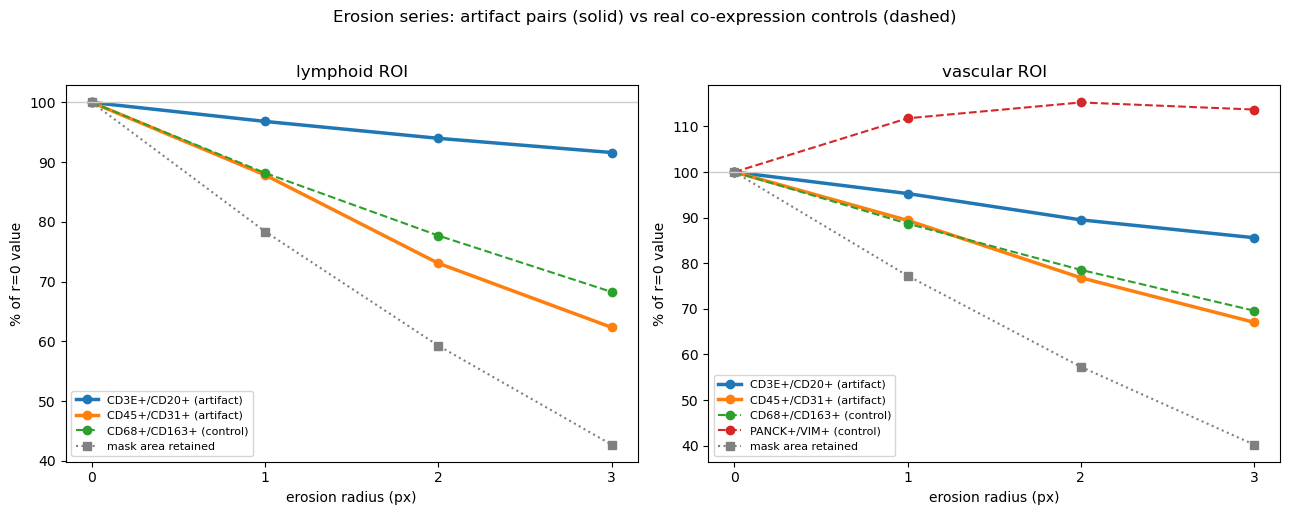

Interpretation: an artifact pair falling much faster than the controls and faster
than mask area implies boundary-borne (lateral) contamination. Tracking the
controls implies the signal is distributed through the mask interior (axial).


In [6]:
fig, axes = plt.subplots(1, len(EROSION), figsize=(6.5 * len(EROSION), 5), squeeze=False)
for ax, (name, df) in zip(axes[0], EROSION.items()):
    for a, b, kind in ALL_PAIRS:
        key = f"{a}+{b}"
        base = df[key].iloc[0]
        if base <= 0:
            continue
        ax.plot(df["radius"], 100 * df[key] / base,
                marker="o",
                ls="-" if kind == "artifact" else "--",
                lw=2.5 if kind == "artifact" else 1.5,
                label=f"{a}+/{b}+ ({kind})")
    ax.plot(df["radius"], df["area_retained_pct"], color="0.5", ls=":", marker="s",
            label="mask area retained")
    ax.axhline(100, color="0.8", lw=1)
    ax.set_xlabel("erosion radius (px)")
    ax.set_ylabel("% of r=0 value")
    ax.set_title(f"{name} ROI")
    ax.set_xticks(EROSION_RADII)
    ax.legend(fontsize=8)
plt.suptitle("Erosion series: artifact pairs (solid) vs real co-expression controls (dashed)", y=1.02)
plt.tight_layout(); plt.show()

print("Interpretation: an artifact pair falling much faster than the controls and faster")
print("than mask area implies boundary-borne (lateral) contamination. Tracking the")
print("controls implies the signal is distributed through the mask interior (axial).")

## 5. Complementary-neighbour test

REDSEA's premise, measured without installing REDSEA. If a CD3E+/CD20+ cell is
double-positive because CD20 bled in from the cell next door, then it should be
**enriched for a CD20 single-positive neighbour** compared with CD3E+ cells that are not
double-positive.

DAPI-only masks leave gaps between nuclei, so raw label adjacency would find almost no
contacts. Labels are first Voronoi-expanded by `NEIGHBOUR_EXPAND` px so that "neighbour"
means "nucleus within a few microns", which is the relevant relation for bleed.

In [7]:
def neighbour_map(mask, expand=NEIGHBOUR_EXPAND):
    lab = expand_labels(mask, distance=expand)
    nb = defaultdict(set)
    for A, B in ((lab[:-1, :], lab[1:, :]), (lab[:, :-1], lab[:, 1:])):
        sel = (A > 0) & (B > 0) & (A != B)
        for u, v in zip(A[sel].tolist(), B[sel].tolist()):
            nb[u].add(v); nb[v].add(u)
    return nb

NEIGHBOUR = {}
for name, (mask, border) in ROI_CACHE.items():
    _, img, _ = load_roi(ROIS[name])
    maxlab = int(mask.max())
    means, cnt = quantify(mask, img, maxlab)
    del img
    valid = cnt > 0; valid[0] = False
    for b in border:
        if b <= maxlab:
            valid[b] = False
    nb = neighbour_map(mask)
    print(f"\n=== {name.upper()} ===")
    for a, b in ARTIFACT_PAIRS:
        pa, pb = positive(means, a), positive(means, b)
        dp    = pa & pb & valid            # double positive
        solo  = pa & ~pb & valid           # A-only: the comparison group
        donor = pb & ~pa & valid           # potential B donors
        def frac_with_donor(group):
            ids = np.flatnonzero(group)
            if ids.size == 0:
                return np.nan, 0
            hit = sum(1 for i in ids if any(donor[j] for j in nb.get(int(i), ()) if j <= maxlab))
            return hit / ids.size, ids.size
        f_dp, n_dp     = frac_with_donor(dp)
        f_solo, n_solo = frac_with_donor(solo)
        enrich = f_dp / f_solo if f_solo else np.nan
        NEIGHBOUR[(name, f"{a}+{b}")] = {"frac_dp": f_dp, "frac_solo": f_solo,
                                         "enrichment": enrich, "n_dp": n_dp, "n_solo": n_solo}
        print(f"  {a}+/{b}+  n={n_dp:>6,}  with a {b}-only neighbour: {100*f_dp:5.1f} %")
        print(f"    vs {a}+/{b}- n={n_solo:>6,}  with a {b}-only neighbour: {100*f_solo:5.1f} %"
              f"   -> enrichment {enrich:.2f}x")


=== LYMPHOID ===
  CD3E+/CD20+  n= 7,391  with a CD20-only neighbour:  33.3 %
    vs CD3E+/CD20- n=   379  with a CD20-only neighbour:   6.9 %   -> enrichment 4.86x
  CD45+/CD31+  n= 1,021  with a CD31-only neighbour:  46.8 %
    vs CD45+/CD31- n= 8,990  with a CD31-only neighbour:   6.9 %   -> enrichment 6.77x



=== VASCULAR ===
  CD3E+/CD20+  n= 3,898  with a CD20-only neighbour:  35.8 %
    vs CD3E+/CD20- n= 4,497  with a CD20-only neighbour:   7.8 %   -> enrichment 4.62x
  CD45+/CD31+  n= 3,905  with a CD31-only neighbour:  79.1 %
    vs CD45+/CD31- n= 4,070  with a CD31-only neighbour:  19.6 %   -> enrichment 4.03x


## 6. Within-mask signal geometry — the per-cell discriminator

For every double-positive cell, compute the intensity-weighted centroid of marker A and of
marker B **over that cell's own pixels**, and measure the offset between them, normalised
by the cell's equivalent radius `sqrt(area/pi)`.

- **Offset near 0** — both markers fill the same footprint. Consistent with axial overlap
  (or a genuine doublet). No 2D segmentation can separate these.
- **Offset near 0.5-1.0 radii** — the markers sit on opposite sides of the mask. Consistent
  with two adjacent cells merged into one label, or with rim bleed. Segmentation can fix these.

Weights use `max(intensity - threshold, 0)` rather than raw intensity. Uniform background
would otherwise drag both centroids toward the geometric centre and manufacture a
false "offset ~ 0" result.

The real co-expression control pairs give the reference distribution for what
"same footprint" looks like when the biology is genuine.

In [8]:
def centroid_offsets(mask, img, border, pair):
    a, b = pair
    maxlab = int(mask.max())
    flat = mask.ravel()
    yy, xx = np.mgrid[0:mask.shape[0], 0:mask.shape[1]]
    yy = yy.ravel().astype(np.float64); xx = xx.ravel().astype(np.float64)
    means, cnt = quantify(mask, img, maxlab)
    valid = cnt > 0; valid[0] = False
    for bb in border:
        if bb <= maxlab:
            valid[bb] = False

    def wcent(marker):
        w = np.clip(img[COL[marker]].ravel().astype(np.float64) - THRESHOLDS[marker], 0, None)
        tot = np.bincount(flat, weights=w,      minlength=maxlab + 1)
        cy  = np.bincount(flat, weights=w * yy, minlength=maxlab + 1)
        cx  = np.bincount(flat, weights=w * xx, minlength=maxlab + 1)
        ok = tot > 0
        oy = np.full(maxlab + 1, np.nan); ox = np.full(maxlab + 1, np.nan)
        oy[ok] = cy[ok] / tot[ok]; ox[ok] = cx[ok] / tot[ok]
        return oy, ox

    ay, ax_ = wcent(a); by, bx = wcent(b)
    dist = np.sqrt((ay - by) ** 2 + (ax_ - bx) ** 2)
    eq_r = np.sqrt(np.maximum(cnt, 1) / np.pi)
    norm = dist / eq_r
    dp = positive(means, a) & positive(means, b) & valid & np.isfinite(norm)
    return norm[dp], int(dp.sum())

GEOMETRY = {}
for name in ROI_CACHE:
    mask, border = ROI_CACHE[name]
    _, img, _ = load_roi(ROIS[name])
    print(f"\n=== {name.upper()} ===")
    for a, b, kind in ALL_PAIRS:
        off, n = centroid_offsets(mask, img, border, (a, b))
        if n < 20:
            print(f"  {a}+/{b}+  n={n} (too few, skipped)")
            continue
        GEOMETRY[(name, f"{a}+{b}")] = {"offsets": off, "kind": kind,
                                        "median": float(np.median(off)), "n": n}
        print(f"  {a}+/{b}+  n={n:>6,}  median offset={np.median(off):.3f} radii   "
              f"frac >0.5 radii={100*np.mean(off > 0.5):5.1f} %   [{kind}]")
    del img


=== LYMPHOID ===


  CD3E+/CD20+  n= 7,391  median offset=0.275 radii   frac >0.5 radii= 16.9 %   [artifact]


  CD45+/CD31+  n= 1,021  median offset=0.665 radii   frac >0.5 radii= 71.1 %   [artifact]


  CD68+/CD163+  n=   601  median offset=0.185 radii   frac >0.5 radii= 11.1 %   [control]


  PANCK+/VIM+  n=0 (too few, skipped)



=== VASCULAR ===


  CD3E+/CD20+  n= 3,898  median offset=0.436 radii   frac >0.5 radii= 41.3 %   [artifact]


  CD45+/CD31+  n= 3,905  median offset=0.487 radii   frac >0.5 radii= 48.3 %   [artifact]


  CD68+/CD163+  n= 2,804  median offset=0.174 radii   frac >0.5 radii=  8.3 %   [control]


  PANCK+/VIM+  n=   583  median offset=0.266 radii   frac >0.5 radii= 13.9 %   [control]


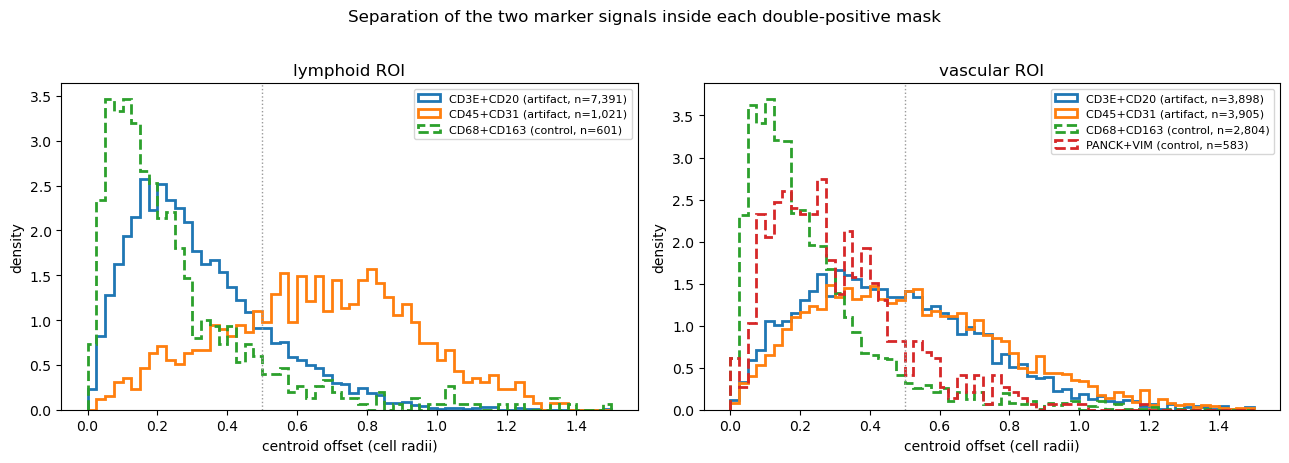

A mass concentrated below ~0.3 radii means the markers are co-located inside the
mask (axial / true doublet). A shoulder beyond 0.5 radii means they are spatially
separated within one mask (lateral / merged neighbours), which segmentation can fix.


In [9]:
fig, axes = plt.subplots(1, len(ROI_CACHE), figsize=(6.5 * len(ROI_CACHE), 4.5), squeeze=False)
for ax, name in zip(axes[0], ROI_CACHE):
    for (rn, key), g in GEOMETRY.items():
        if rn != name:
            continue
        ax.hist(g["offsets"], bins=60, range=(0, 1.5), density=True, histtype="step", lw=2,
                ls="-" if g["kind"] == "artifact" else "--",
                label=f"{key} ({g['kind']}, n={g['n']:,})")
    ax.axvline(0.5, color="0.6", ls=":", lw=1)
    ax.set_xlabel("centroid offset (cell radii)")
    ax.set_ylabel("density")
    ax.set_title(f"{name} ROI")
    ax.legend(fontsize=8)
plt.suptitle("Separation of the two marker signals inside each double-positive mask", y=1.02)
plt.tight_layout(); plt.show()

print("A mass concentrated below ~0.3 radii means the markers are co-located inside the")
print("mask (axial / true doublet). A shoulder beyond 0.5 radii means they are spatially")
print("separated within one mask (lateral / merged neighbours), which segmentation can fix.")

## 7. Summary

Writes `output/spillover_diagnostic_summary.csv`. The decisive column is
`rim_attributable_pct`: the share of the baseline double-positive rate that disappears
once an r=2 rim is removed. That is the **upper bound** on what better segmentation plus
REDSEA can recover. The remainder, `residual_floor_pct`, is the irreducible 2D floor and
is only addressable by segmentation-aware clustering.

The rim fraction is only meaningful relative to the controls: erosion shrinks every mask
and adds noise, so some decay is expected even for genuine co-expression. `control_decay_pct`
is that null effect. If an artifact pair does not decay appreciably faster than the
controls, its apparent rim effect is an artefact of erosion itself, not evidence of
lateral spillover.

In [10]:
R_TEST = 2
rows = []
for name, df in EROSION.items():
    d = df.set_index("radius")
    ctrl = [f"{a}+{b}" for a, b in CONTROL_PAIRS
            if d.loc[0, f"{a}+{b}"] > 0.05]
    ctrl_decay = float(np.mean([100 * (1 - d.loc[R_TEST, k] / d.loc[0, k]) for k in ctrl])) if ctrl else np.nan
    for a, b, kind in ALL_PAIRS:
        key = f"{a}+{b}"
        base, ero = float(d.loc[0, key]), float(d.loc[R_TEST, key])
        if base <= 0:
            continue
        rim = 100 * (1 - ero / base)
        g  = GEOMETRY.get((name, key), {})
        nb = NEIGHBOUR.get((name, key), {})
        rows.append({
            "roi": name, "pair": key, "kind": kind,
            "slide_wide_pct": slide_rates.get(key, np.nan),
            "roi_baseline_pct": base,
            f"roi_r{R_TEST}_pct": ero,
            "rim_attributable_pct": rim,
            "control_decay_pct": ctrl_decay,
            "excess_over_control_pct": rim - ctrl_decay,
            "residual_floor_pct": 100 - rim,
            "neighbour_enrichment": nb.get("enrichment", np.nan),
            "median_centroid_offset_radii": g.get("median", np.nan),
            "frac_offset_gt_half": float(np.mean(g["offsets"] > 0.5)) if "offsets" in g else np.nan,
            "n_double_positive": g.get("n", np.nan),
            "mask_area_retained_pct": float(d.loc[R_TEST, "area_retained_pct"]),
        })

summary = pd.DataFrame(rows)
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUT_CSV, index=False)
print(f"wrote {OUT_CSV}\n")
print(summary.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

wrote /home/steve/Projects/HeLab/BladderDIVE/output/spillover_diagnostic_summary.csv

     roi       pair     kind  slide_wide_pct  roi_baseline_pct  roi_r2_pct  rim_attributable_pct  control_decay_pct  excess_over_control_pct  residual_floor_pct  neighbour_enrichment  median_centroid_offset_radii  frac_offset_gt_half  n_double_positive  mask_area_retained_pct
lymphoid  CD3E+CD20 artifact           10.79             63.92       60.08                  6.01              22.30                   -16.29               93.99                  4.86                          0.28                 0.17               7391                   59.27
lymphoid  CD45+CD31 artifact            5.75              8.83        6.45                 26.93              22.30                     4.64               73.07                  6.77                          0.67                 0.71               1021                   59.27
lymphoid CD68+CD163  control            6.95              5.20        4.04         

In [11]:
print("=" * 78)
print("VERDICT")
print("=" * 78)
for _, r in summary[summary.kind == "artifact"].iterrows():
    excess = r["excess_over_control_pct"]
    off    = r["median_centroid_offset_radii"]
    enr    = r["neighbour_enrichment"]
    votes = []
    votes.append("lateral" if excess > 15 else "axial")
    votes.append("lateral" if off > 0.35 else "axial")
    votes.append("lateral" if (np.isfinite(enr) and enr > 1.3) else "axial")
    verdict = "LATERAL" if votes.count("lateral") >= 2 else "AXIAL"
    print(f"\n{r['roi']:9s} {r['pair']:12s} baseline {r['roi_baseline_pct']:5.2f} % of ROI cells")
    print(f"  erosion r=2 removes {r['rim_attributable_pct']:5.1f} % of them, "
          f"controls lose {r['control_decay_pct']:5.1f} % -> excess {excess:+5.1f} pts  [{votes[0]}]")
    print(f"  median centroid offset {off:.3f} radii "
          f"({100*r['frac_offset_gt_half']:.0f} % beyond 0.5)                    [{votes[1]}]")
    print(f"  complementary-neighbour enrichment {enr:.2f}x"
          f"                              [{votes[2]}]")
    print(f"  --> {verdict}")
print()
print("LATERAL -> whole-cell segmentation (Step 3) and REDSEA (Step 5) will pay off.")
print("AXIAL   -> no 2D segmenter can help; STARLING (Step 6) becomes the primary fix,")
print("           and segmentation work should be judged against this floor, not against zero.")

VERDICT

lymphoid  CD3E+CD20    baseline 63.92 % of ROI cells
  erosion r=2 removes   6.0 % of them, controls lose  22.3 % -> excess -16.3 pts  [axial]
  median centroid offset 0.275 radii (17 % beyond 0.5)                    [axial]
  complementary-neighbour enrichment 4.86x                              [lateral]
  --> AXIAL

lymphoid  CD45+CD31    baseline  8.83 % of ROI cells
  erosion r=2 removes  26.9 % of them, controls lose  22.3 % -> excess  +4.6 pts  [axial]
  median centroid offset 0.665 radii (71 % beyond 0.5)                    [lateral]
  complementary-neighbour enrichment 6.77x                              [lateral]
  --> LATERAL

vascular  CD3E+CD20    baseline 17.47 % of ROI cells
  erosion r=2 removes  10.5 % of them, controls lose   3.1 % -> excess  +7.4 pts  [axial]
  median centroid offset 0.436 radii (41 % beyond 0.5)                    [lateral]
  complementary-neighbour enrichment 4.62x                              [lateral]
  --> LATERAL

vascular  CD45+CD31    